# Notebook 01: Data Exploration
## Hormuz Shock Propagation Model

This notebook explores the real Brent Crude price series pulled from Yahoo Finance
and the conflict events timeline built for the 2026 Iran war. Before any modelling,
we want to understand the data clearly: how prices moved across regimes, how
volatility changed when the war started, and how conflict features relate to price.

**Data used in this notebook**

- Live Brent Crude OHLCV via yfinance (BZ=F), Jan 2024 to present
- 20 hand-coded conflict events from the 2026 Iran war timeline
- Derived features: log returns, rolling volatility, Hormuz closure flags

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#333344',
    'axes.labelcolor':  '#aaaaaa',
    'text.color':       '#cccccc',
    'xtick.color':      '#aaaaaa',
    'ytick.color':      '#aaaaaa',
    'grid.color':       '#2a2d3a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
})

In [3]:
ticker = yf.Ticker("BZ=F")
brent = ticker.history(start="2024-01-01", interval="1d")

brent.index = pd.to_datetime(brent.index).tz_localize(None)
brent.index.name = "date"
brent.columns = [c.lower() for c in brent.columns]
brent = brent[["open", "high", "low", "close", "volume"]]
brent = brent[brent["close"] > 0].dropna(subset=["close"])

print(f"Rows fetched  : {len(brent)}")
print(f"Date range    : {brent.index.min().date()} to {brent.index.max().date()}")
print(f"Price range   : ${brent['close'].min():.2f} to ${brent['close'].max():.2f}")
brent.tail(5)

Rows fetched  : 577
Date range    : 2024-01-02 to 2026-04-17
Price range   : $58.92 to $118.35


,open,high,low,close,volume
date,,,,,
2026-04-13,99.709999,103.860001,97.639999,99.360001,50559
2026-04-14,98.419998,99.410004,94.430000,94.790001,40991
2026-04-15,95.519997,96.889999,91.000000,94.930000,41928
2026-04-16,94.910004,99.839996,94.419998,99.389999,36540
2026-04-17,98.250000,98.970001,86.080002,90.379997,82451


## Conflic Events

In [4]:
# conflict events hand-coded from Wikipedia, Britannica, Al Jazeera
CONFLICT_EVENTS = [
    {"date": "2025-10-01", "event": "US-Iran nuclear talks collapse; new sanctions imposed",
     "category": "diplomatic", "escalation": 2, "de_escalation": 0, "hormuz_threat": False},
    {"date": "2025-12-15", "event": "Israel strikes Iranian proxy sites in Syria",
     "category": "military", "escalation": 2, "de_escalation": 0, "hormuz_threat": False},
    {"date": "2026-01-20", "event": "US deploys carrier strike group to Persian Gulf",
     "category": "military", "escalation": 3, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-02-10", "event": "Iran conducts large-scale Hormuz closure drill",
     "category": "military", "escalation": 3, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-02-28", "event": "Operation Epic Fury begins - US/Israel strikes on Iran; Khamenei killed",
     "category": "military", "escalation": 5, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-03-01", "event": "Iran launches hundreds of drones and ballistic missiles across the region",
     "category": "military", "escalation": 5, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-03-01", "event": "Dubai International Airport struck by drone; flights suspended",
     "category": "infrastructure", "escalation": 4, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-03-02", "event": "Strait of Hormuz closure - Iran bars commercial shipping",
     "category": "economic", "escalation": 5, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-03-03", "event": "Israel strikes Assembly of Experts building",
     "category": "military", "escalation": 4, "de_escalation": 0, "hormuz_threat": False},
    {"date": "2026-03-05", "event": "Mojtaba Khamenei appointed as new supreme leader",
     "category": "political", "escalation": 2, "de_escalation": 0, "hormuz_threat": False},
    {"date": "2026-03-07", "event": "US naval blockade of Iranian ports begins",
     "category": "military", "escalation": 4, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-03-10", "event": "USS Charlotte sinks Iranian frigate IRIS Dena in Indian Ocean",
     "category": "military", "escalation": 4, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-03-20", "event": "Trump postpones strikes on Iranian power plants; peace talks hinted",
     "category": "diplomatic", "escalation": 0, "de_escalation": 3, "hormuz_threat": False},
    {"date": "2026-03-24", "event": "Iran rejects US 15-point peace plan",
     "category": "diplomatic", "escalation": 2, "de_escalation": 0, "hormuz_threat": False},
    {"date": "2026-03-28", "event": "Houthis fire ballistic missiles at Israel; 2,500 US Marines arrive",
     "category": "military", "escalation": 3, "de_escalation": 0, "hormuz_threat": True},
    {"date": "2026-04-05", "event": "Iran partially reopens Strait of Hormuz for non-hostile vessels",
     "category": "economic", "escalation": 0, "de_escalation": 4, "hormuz_threat": False},
    {"date": "2026-04-11", "event": "UK and France announce multinational Hormuz navigation mission",
     "category": "diplomatic", "escalation": 1, "de_escalation": 2, "hormuz_threat": False},
    {"date": "2026-04-17", "event": "Iran reopens Strait of Hormuz fully; Brent falls sharply",
     "category": "economic", "escalation": 0, "de_escalation": 4, "hormuz_threat": False},
    {"date": "2026-04-18", "event": "Iran closes Strait again pending US port blockade lift",
     "category": "economic", "escalation": 3, "de_escalation": 0, "hormuz_threat": True},
]

events = pd.DataFrame(CONFLICT_EVENTS)
events["date"] = pd.to_datetime(events["date"])
print(f"Events loaded: {len(events)}")
events[["date", "event", "category", "escalation", "hormuz_threat"]].head(8)

Events loaded: 19


,date,event,category,escalation,hormuz_threat
0,2025-10-01,US-Iran nuclear talks collapse; new sanctions ...,diplomatic,2,False
1,2025-12-15,Israel strikes Iranian proxy sites in Syria,military,2,False
2,2026-01-20,US deploys carrier strike group to Persian Gulf,military,3,True
3,2026-02-10,Iran conducts large-scale Hormuz closure drill,military,3,True
4,2026-02-28,Operation Epic Fury begins - US/Israel strikes...,military,5,True
5,2026-03-01,Iran launches hundreds of drones and ballistic...,military,5,True
6,2026-03-01,Dubai International Airport struck by drone; f...,infrastructure,4,True
7,2026-03-02,Strait of Hormuz closure - Iran bars commercia...,economic,5,True


In [ ]:
# display of the events table
display_cols = ['date', 'event', 'category', 'escalation', 'de_escalation', 'hormuz_threat']
events_display = events[display_cols].copy()
events_display['date'] = events_display['date'].dt.strftime('%Y-%m-%d')
events_display['hormuz_threat'] = events_display['hormuz_threat'].map({True: 'YES', False: 'no'})

pd.set_option('display.max_colwidth', 70)
pd.set_option('display.max_rows', 25)
print(f'Total events: {len(events_display)}')
print(f'Date range  : {events_display["date"].min()} → {events_display["date"].max()}')
print()
events_display

In [ ]:
# Escalation vs de-escalation over time
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Top: cumulative net conflict score on the panel
ax = axes[0]
ax.plot(panel.index, panel['net_conflict_7d'], color='#e74c3c', linewidth=1.5)
ax.fill_between(panel.index, panel['net_conflict_7d'], 0,
                where=panel['net_conflict_7d'] > 0, alpha=0.2, color='#e74c3c', label='Net escalation')
ax.fill_between(panel.index, panel['net_conflict_7d'], 0,
                where=panel['net_conflict_7d'] < 0, alpha=0.2, color='#2ecc71', label='Net de-escalation')
ax.axhline(0, color='white', linewidth=0.6, alpha=0.4)
ax.set_ylabel('Net conflict score\n(7-day rolling)')
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)

# Bottom: Hormuz closed flag
ax = axes[1]
ax.fill_between(panel.index, panel['hormuz_closed'], alpha=0.4, color='#e74c3c', label='Hormuz closed')
ax.set_ylabel('Hormuz closed\n(binary)')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Open', 'Closed'])
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

fig.suptitle('Conflict Intensity and Hormuz Status Over Time', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/01_conflict_timeline.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [5]:
# log returns
brent["daily_return"] = np.log(brent["close"] / brent["close"].shift(1))

# aggregate events to daily
esc = (
    events.groupby("date").agg(
        escalation_score=("escalation", "sum"),
        de_escalation_score=("de_escalation", "sum"),
        hormuz_threat=("hormuz_threat", "max"),
        n_events=("event", "count"),
    ).astype({"hormuz_threat": int})
)

panel = brent.join(esc, how="left")
panel[["escalation_score", "de_escalation_score", "hormuz_threat", "n_events"]] = (
    panel[["escalation_score", "de_escalation_score", "hormuz_threat", "n_events"]].fillna(0)
)

# net conflict score rolling 7 days
panel["net_conflict_raw"] = panel["escalation_score"] - panel["de_escalation_score"]
panel["net_conflict_7d"]  = panel["net_conflict_raw"].rolling(7, min_periods=1).sum()

# war period flag
panel["war_period"] = (panel.index >= pd.Timestamp("2026-02-28")).astype(int)

# Hormuz closure windows from confirmed reporting
closure_windows = [
    ("2026-03-02", "2026-04-04"),
    ("2026-04-18", "2099-12-31"),
]
panel["hormuz_closed"] = 0
for s, e in closure_windows:
    panel.loc[(panel.index >= s) & (panel.index <= e), "hormuz_closed"] = 1

# moving averages and volatility
panel["ma_5"]          = panel["close"].rolling(5).mean()
panel["ma_20"]         = panel["close"].rolling(20).mean()
panel["volatility_10d"] = panel["daily_return"].rolling(10).std()

panel = panel.dropna(subset=["daily_return"])

print(f"Panel shape   : {panel.shape}")
print(f"War-period rows: {panel['war_period'].sum()}")
print(f"Price range   : ${panel['close'].min():.2f} to ${panel['close'].max():.2f}")
panel.tail(3)

Panel shape   : (576, 17)
War-period rows: 34
Price range   : $58.92 to $118.35


,open,high,low,close,volume,daily_return,escalation_score,de_escalation_score,hormuz_threat,n_events,net_conflict_raw,net_conflict_7d,war_period,hormuz_closed,ma_5,ma_20,volatility_10d
date,,,,,,,,,,,,,,,,,
2026-04-15,95.519997,96.889999,91.000000,94.930000,41928,0.001476,0.0,0.0,0.0,0.0,0.0,0.0,1,0,96.039999,104.5380,0.074560
2026-04-16,94.910004,99.839996,94.419998,99.389999,36540,0.045912,0.0,0.0,0.0,0.0,0.0,0.0,1,0,96.734000,104.1385,0.059946
2026-04-17,98.250000,98.970001,86.080002,90.379997,82451,-0.095029,0.0,4.0,0.0,1.0,-4.0,-4.0,1,0,95.770000,103.2250,0.059880


## Price Series with War Period Overlay

The chart below shows the full price history from January 2024. The red section
is the war period starting 28 February 2026. Key Hormuz events are annotated
directly on the chart.

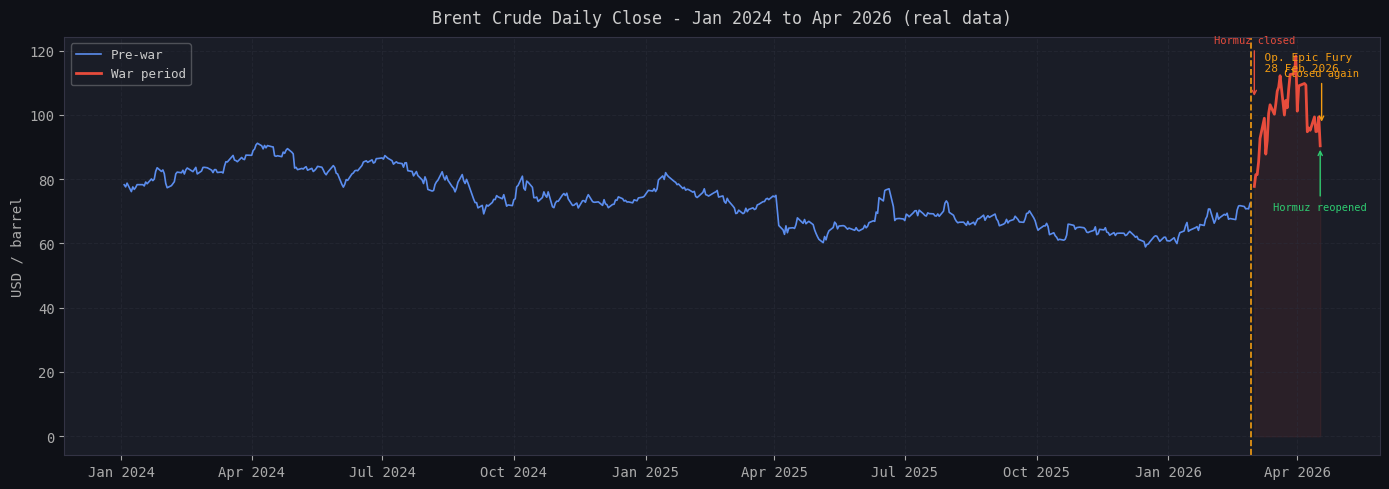

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

pre = panel[panel["war_period"] == 0]
war = panel[panel["war_period"] == 1]

ax.plot(pre.index, pre["close"], color="#5b8dee", linewidth=1.2, label="Pre-war")
ax.plot(war.index, war["close"], color="#e74c3c", linewidth=2.0, label="War period")
ax.fill_between(war.index, war["close"], alpha=0.08, color="#e74c3c")

ax.axvline(pd.Timestamp("2026-02-28"), color="#f39c12", linestyle="--", linewidth=1.2)
ax.text(pd.Timestamp("2026-02-28"), panel["close"].max() * 0.96,
        "  Op. Epic Fury\n  28 Feb 2026", color="#f39c12", fontsize=8)

key_annotations = [
    ("2026-03-02", "Hormuz closed",   105, "#e74c3c",  40),
    ("2026-04-17", "Hormuz reopened",  90, "#2ecc71", -45),
    ("2026-04-18", "Closed again",     97, "#f39c12",  35),
]
for date, label, price, color, yoffset in key_annotations:
    ax.annotate(label,
                xy=(pd.Timestamp(date), price),
                xytext=(0, yoffset), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color=color, lw=1.0),
                color=color, fontsize=7.5, ha="center")

ax.set_title("Brent Crude Daily Close - Jan 2024 to Apr 2026 (real data)", fontsize=12, pad=10)
ax.set_ylabel("USD / barrel")
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.savefig("../outputs/01_price_series.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## Conflict Events Timeline

This shows how escalation and de-escalation events distributed over the period,
and when the Hormuz strait was confirmed closed.

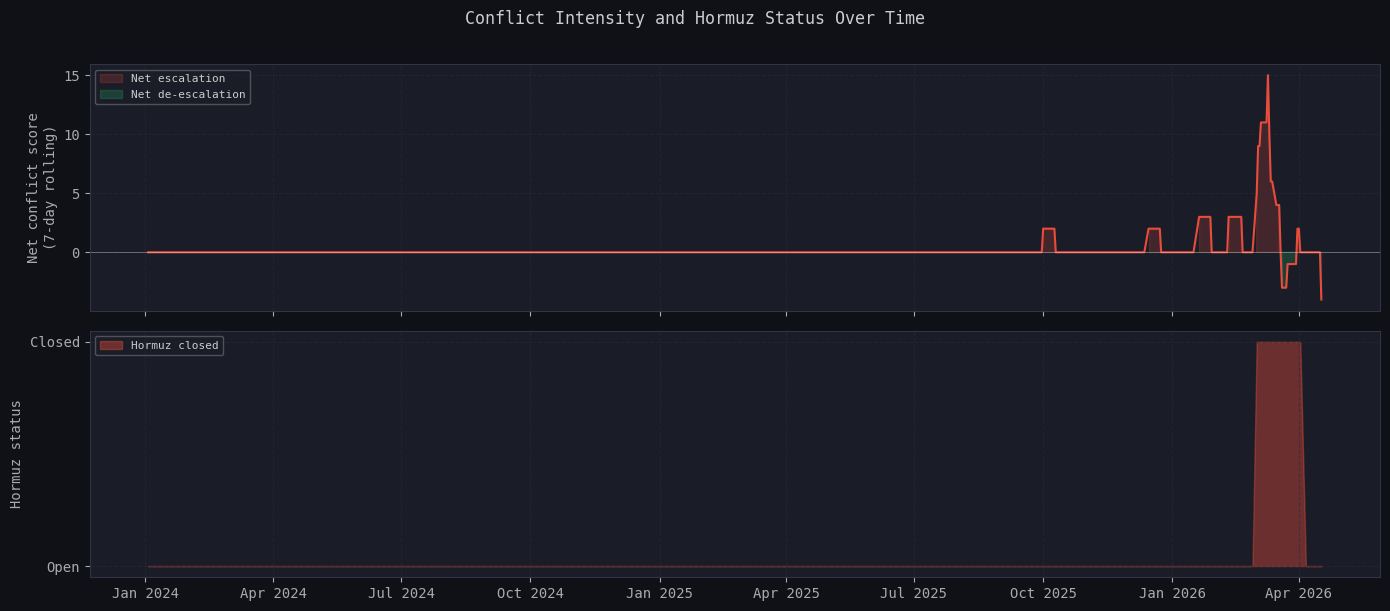

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ax.plot(panel.index, panel["net_conflict_7d"], color="#e74c3c", linewidth=1.5)
ax.fill_between(panel.index, panel["net_conflict_7d"], 0,
                where=panel["net_conflict_7d"] > 0, alpha=0.2, color="#e74c3c", label="Net escalation")
ax.fill_between(panel.index, panel["net_conflict_7d"], 0,
                where=panel["net_conflict_7d"] < 0, alpha=0.2, color="#2ecc71", label="Net de-escalation")
ax.axhline(0, color="white", linewidth=0.6, alpha=0.4)
ax.set_ylabel("Net conflict score\n(7-day rolling)")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)

ax = axes[1]
ax.fill_between(panel.index, panel["hormuz_closed"], alpha=0.4, color="#e74c3c", label="Hormuz closed")
ax.set_ylabel("Hormuz status")
ax.set_yticks([0, 1])
ax.set_yticklabels(["Open", "Closed"])
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.suptitle("Conflict Intensity and Hormuz Status Over Time", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/01_conflict_timeline.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

## Volatility Regime Comparison

One of the clearest signals in the data is how much noisier daily returns became
once the war started. The charts below show the return distribution and rolling
volatility side by side across the two regimes.

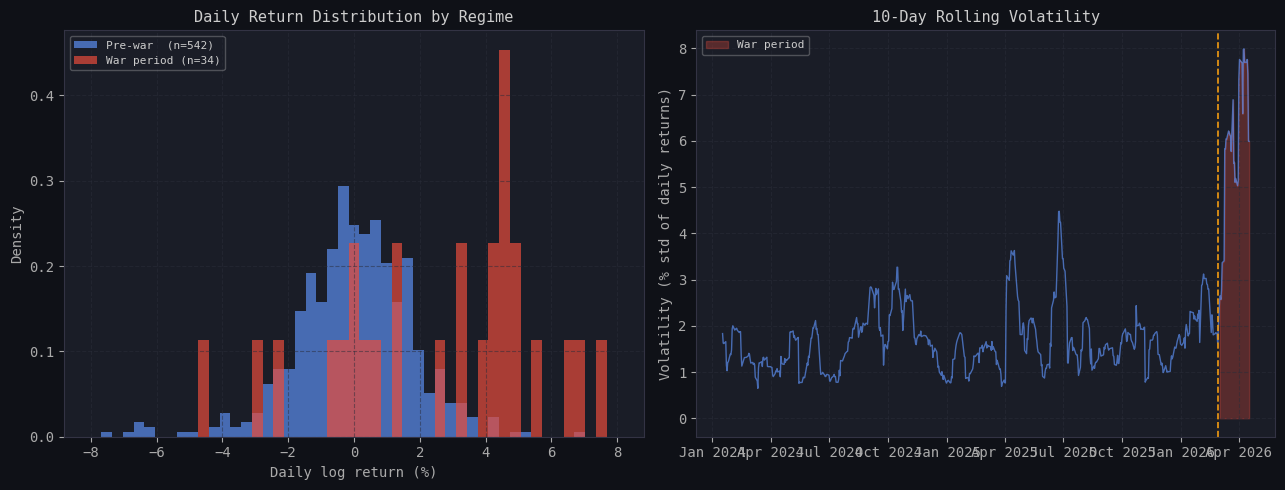

Pre-war daily vol  : 1.780%
War period daily vol: 6.447%
Volatility ratio    : 3.62x higher during war


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pre_r = pre["daily_return"].dropna() * 100
war_r = war["daily_return"].dropna() * 100

ax = axes[0]
bins = np.linspace(-8, 8, 50)
ax.hist(pre_r, bins=bins, color="#5b8dee", alpha=0.7, density=True, label=f"Pre-war  (n={len(pre_r)})")
ax.hist(war_r, bins=bins, color="#e74c3c", alpha=0.7, density=True, label=f"War period (n={len(war_r)})")
ax.set_title("Daily Return Distribution by Regime", fontsize=11)
ax.set_xlabel("Daily log return (%)")
ax.set_ylabel("Density")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)

ax = axes[1]
ax.plot(panel.index, panel["volatility_10d"] * 100, color="#5b8dee", linewidth=1.0, alpha=0.7)
ax.fill_between(panel.index, panel["volatility_10d"] * 100,
                where=panel["war_period"] == 1,
                alpha=0.3, color="#e74c3c", label="War period")
ax.axvline(pd.Timestamp("2026-02-28"), color="#f39c12", linestyle="--", linewidth=1.2)
ax.set_title("10-Day Rolling Volatility", fontsize=11)
ax.set_ylabel("Volatility (% std of daily returns)")
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(True)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.savefig("../outputs/01_volatility_regimes.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

ratio = war_r.std() / pre_r.std()
print(f"Pre-war daily vol  : {pre_r.std():.3f}%")
print(f"War period daily vol: {war_r.std():.3f}%")
print(f"Volatility ratio    : {ratio:.2f}x higher during war")

## Feature Correlation Matrix

This checks how the conflict features we built relate to price level and daily returns.
The key question is whether conflict features carry independent signal on top of price lags.

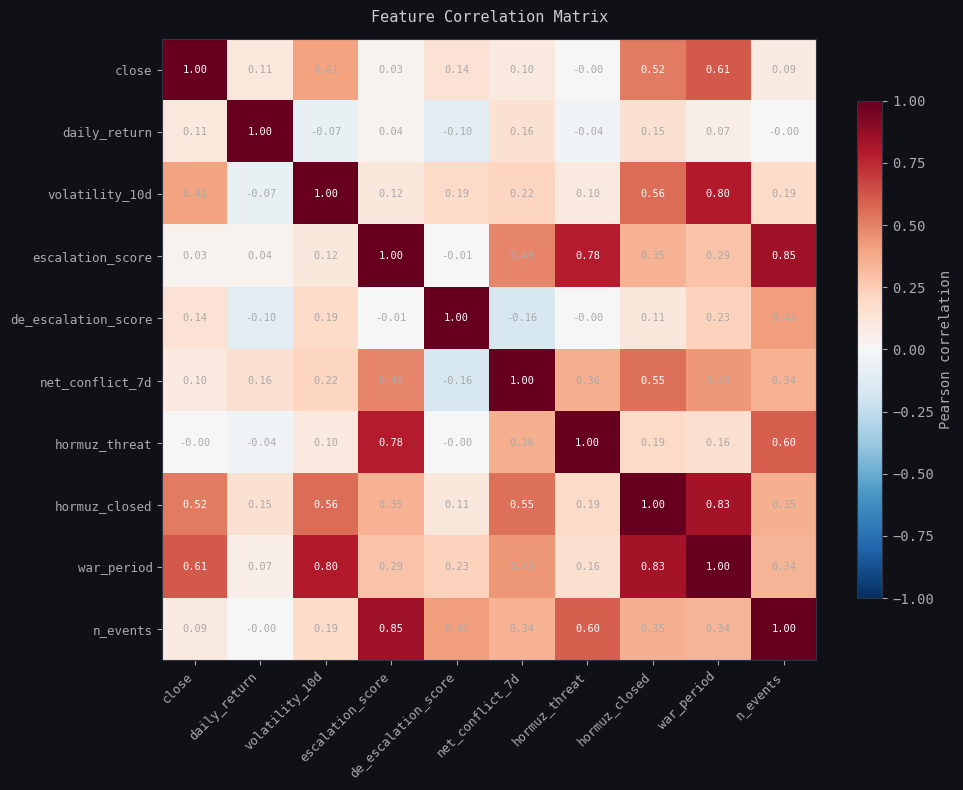

In [10]:
corr_cols = [
    "close", "daily_return", "volatility_10d",
    "escalation_score", "de_escalation_score", "net_conflict_7d",
    "hormuz_threat", "hormuz_closed", "war_period", "n_events",
]

corr = panel[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.values[i, j]
        color = "white" if abs(val) > 0.5 else "#aaaaaa"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7.5, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Feature Correlation Matrix", fontsize=11, pad=12)
plt.tight_layout()
plt.savefig("../outputs/01_correlation_heatmap.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

##Regime Summary Table

In [11]:
summary = panel.groupby("war_period").agg(
    n_days        = ("close", "count"),
    price_min     = ("close", "min"),
    price_max     = ("close", "max"),
    price_mean    = ("close", "mean"),
    daily_vol_pct = ("daily_return", "std"),
    avg_escalation = ("escalation_score", "mean"),
    hormuz_closed_pct = ("hormuz_closed", "mean"),
).round(3)

summary.index = ["Pre-war", "War period"]
summary["daily_vol_pct"]      = (summary["daily_vol_pct"] * 100).round(3)
summary["hormuz_closed_pct"]  = (summary["hormuz_closed_pct"] * 100).round(1)
summary.columns = [
    "N days", "Price min", "Price max", "Price mean",
    "Daily vol (%)", "Avg escalation", "Hormuz closed (%)"
]
summary

,N days,Price min,Price max,Price mean,Daily vol (%),Avg escalation,Hormuz closed (%)
Pre-war,542,58.92,91.17,73.459,1.8,0.018,0.0
War period,34,77.74,118.35,99.563,6.4,0.500,70.6
